In [1]:
# ==========================================
# PHASE 1 MASTER CODE: CLEANING & VISUALIZATION
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from google.colab import drive

In [2]:
# ---------------------------------------------------------
# 1. SETUP & DATA LOADING
# ---------------------------------------------------------
# Mount Google Drive
drive.mount('/content/drive')

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
# REPLACE THIS PATH with your actual file path
file_path = '/content/drive/MyDrive/Crest/employee_attrition_dataset.csv'
df = pd.read_csv(file_path)

print("Data loaded successfully!")
print(f"Initial Shape: {df.shape}")

Mounted at /content/drive
Data loaded successfully!
Initial Shape: (1000, 26)


In [3]:
# ---------------------------------------------------------
# 2. DATA TYPE CONVERSION
# ---------------------------------------------------------
# We convert these specific columns to 'category' so Python treats them as groups, not math numbers.
cols_to_convert = [
    'Gender', 'Marital_Status', 'Department', 'Job_Role', 'Job_Level',
    'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating',
    'Overtime', 'Work_Environment_Satisfaction', 'Relationship_with_Manager',
    'Job_Involvement', 'Attrition'
]

for col in cols_to_convert:
    df[col] = df[col].astype('category')

print("Data types converted. Starting Visualization...")

Data types converted. Starting Visualization...


In [4]:
# ---------------------------------------------------------
# 3. SEPARATE VARIABLES
# ---------------------------------------------------------
cat_cols = df.select_dtypes(include=['category']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Exclude Employee_ID from analysis (it's just an identifier)
if 'Employee_ID' in num_cols:
    num_cols.remove('Employee_ID')


--- GRID 1: Categorical Variables (Bar Charts) ---


/tmp/ipython-input-3041058662.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis', ax=axes[i], order=df[col].value_counts().index)
/tmp/ipython-input-3041058662.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis', ax=axes[i], order=df[col].value_counts().index)
/tmp/ipython-input-3041058662.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis', ax=axes[i], order=df[col].value_counts().index)
/tmp/ipython-input-3041058662.py:13: Future

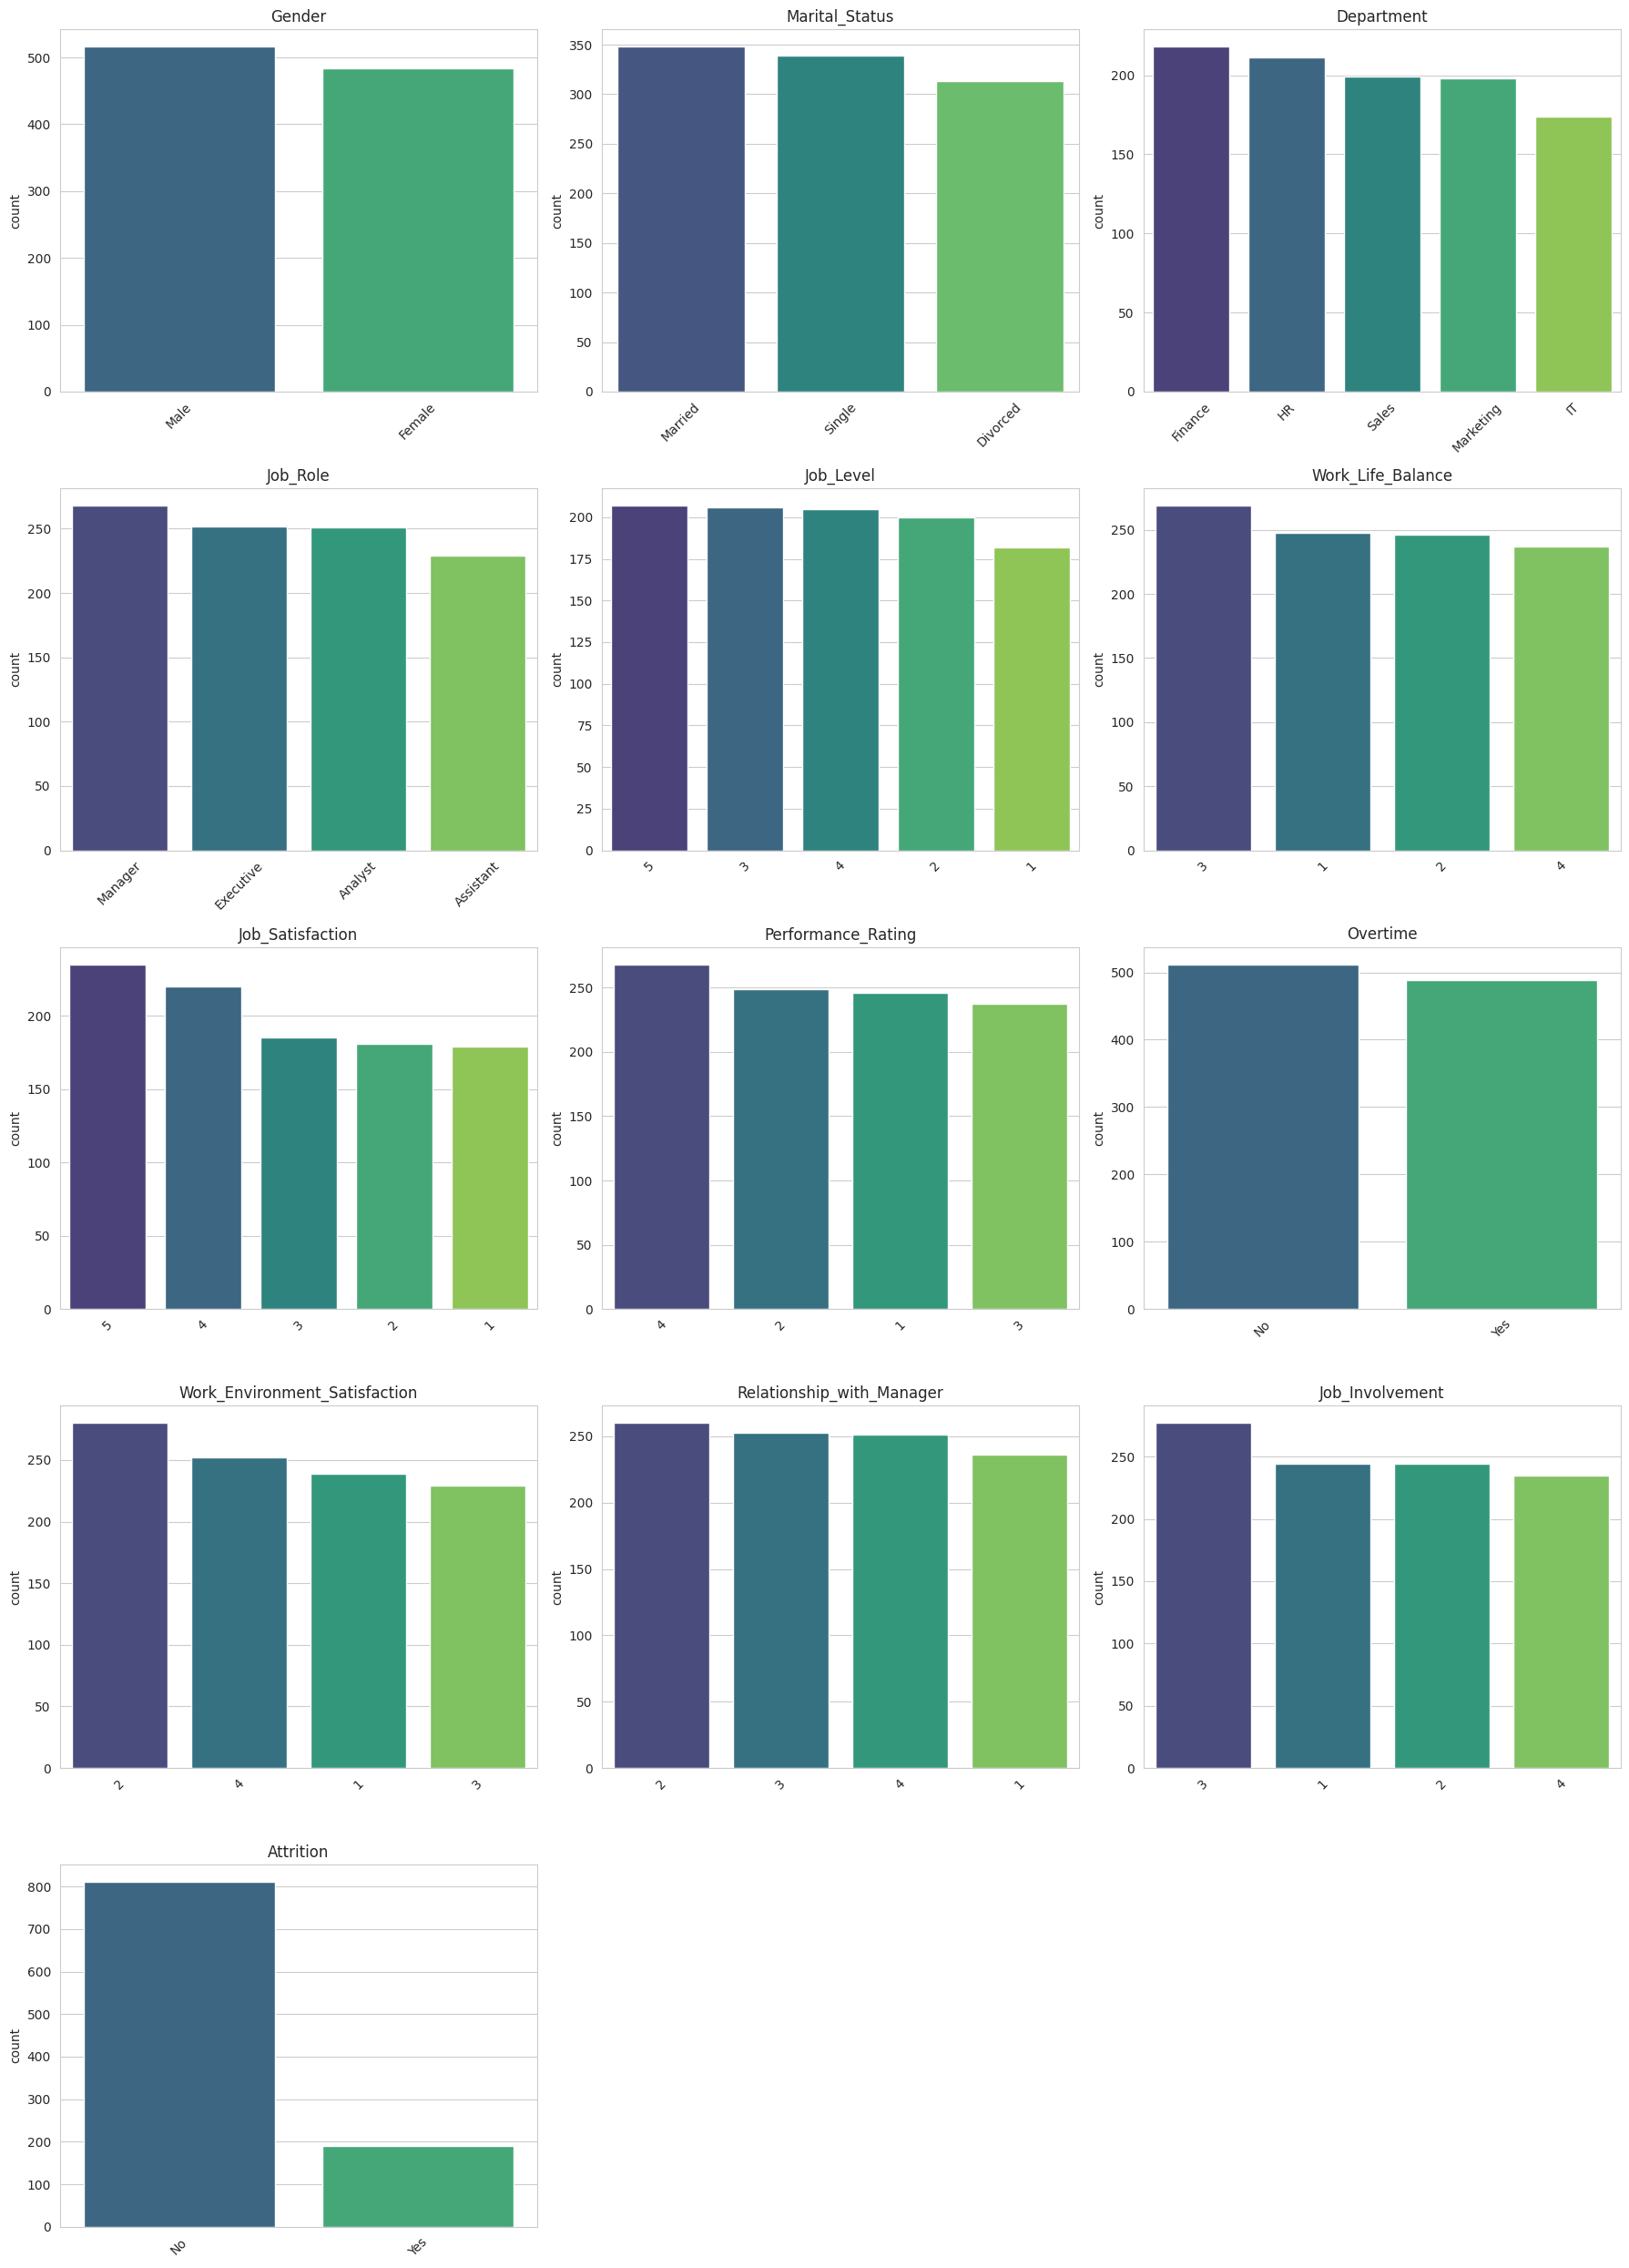

In [5]:
# ---------------------------------------------------------
# 4. CATEGORICAL PLOTS (The Grid)
# ---------------------------------------------------------
print("\n--- GRID 1: Categorical Variables (Bar Charts) ---")
num_plots = len(cat_cols)
cols = 3
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, palette='viridis', ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


--- GRID 2: Numerical Distributions (Histograms) ---


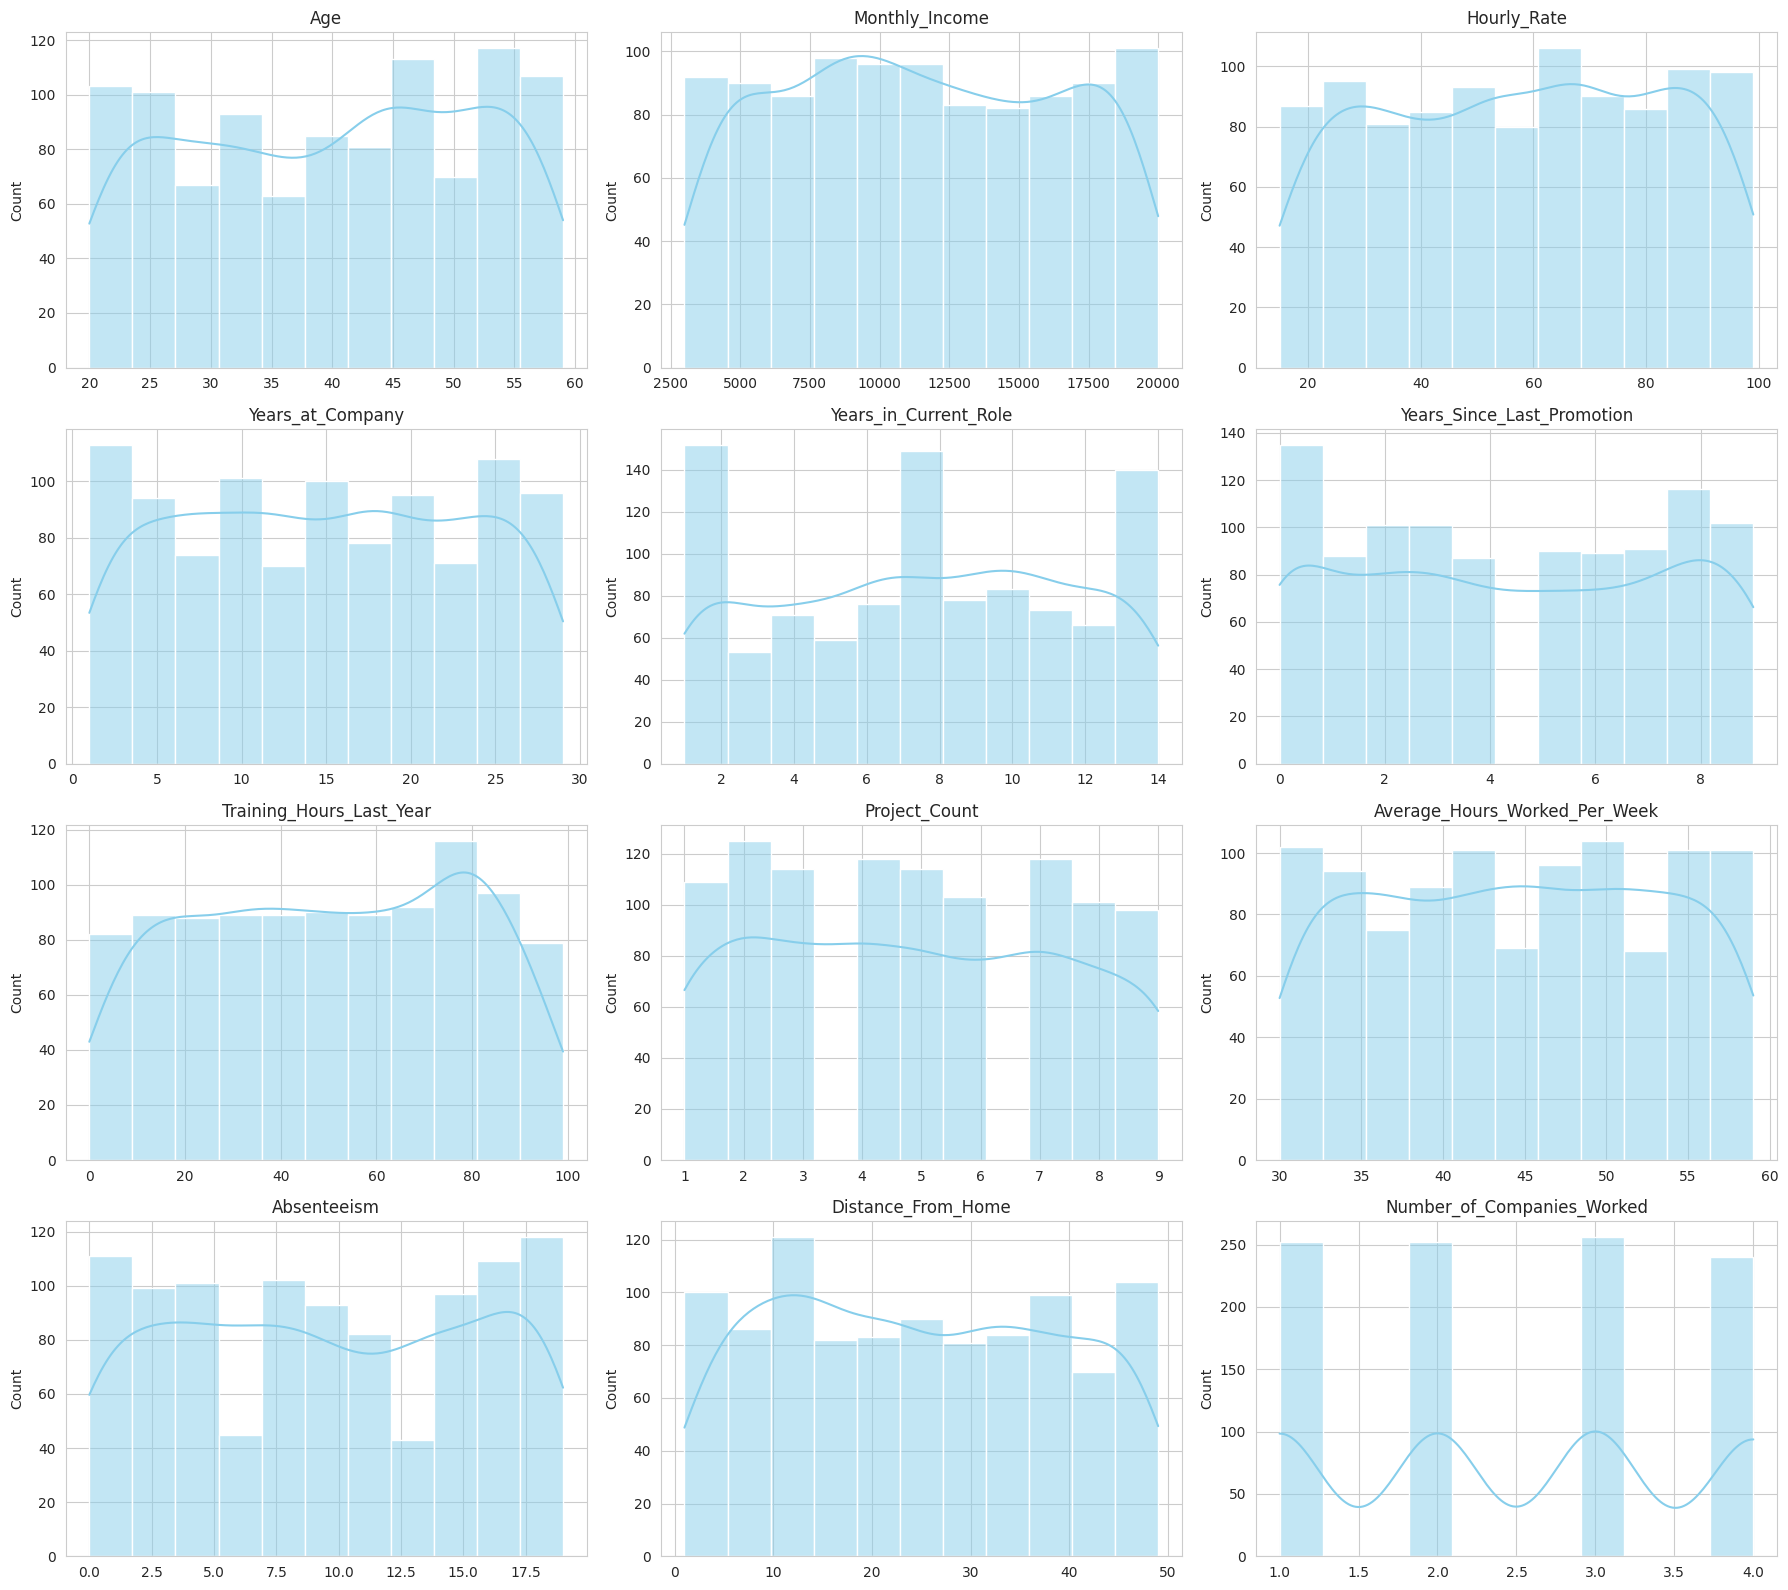

In [6]:
# ---------------------------------------------------------
# 5. NUMERICAL PLOTS (The Grid)
# ---------------------------------------------------------
print("\n--- GRID 2: Numerical Distributions (Histograms) ---")
num_plots = len(num_cols)
cols = 3
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

--- Generating 3D Plot: Age vs Income vs Tenure ---


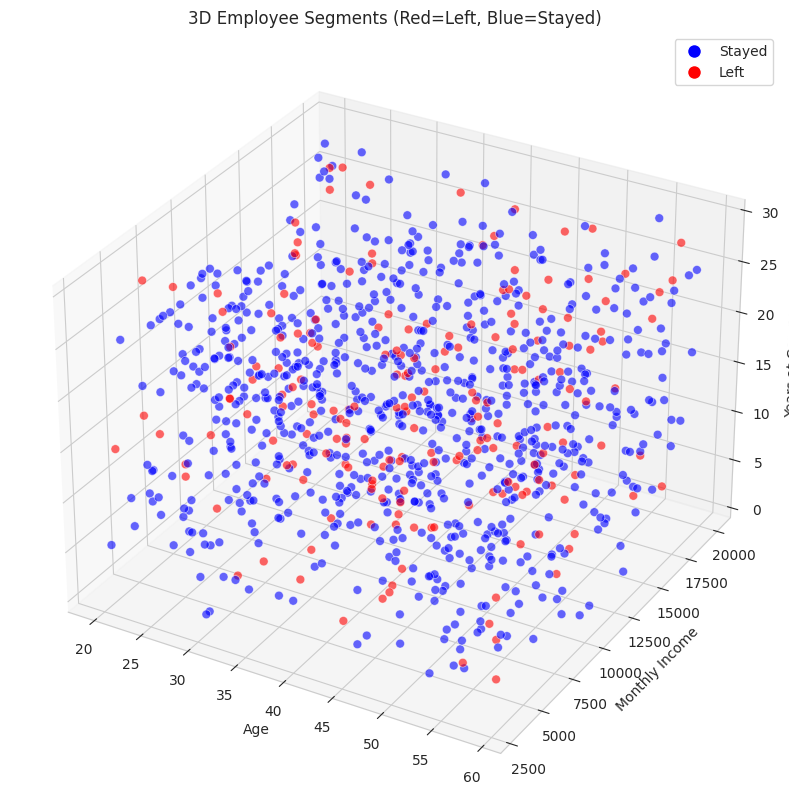

In [22]:
# ==========================================
# VISUALIZATION: 3D SCATTER PLOT (3 SPECIFIC VARIABLES)
# ==========================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

print("--- Generating 3D Plot: Age vs Income vs Tenure ---")

# 1. Setup the 3 Variables
x = df['Age']
y = df['Monthly_Income']
z = df['Years_at_Company']

# 2. Define Colors (Red = Left, Blue = Stayed)
# We map the 'Attrition' column directly
colors = df['Attrition'].map({'Yes': 'red', 'No': 'blue'})

# 3. Create Plot
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c=colors, alpha=0.6, s=40, edgecolors='w', linewidth=0.5)

# 4. Labels & Title
ax.set_xlabel('Age')
ax.set_ylabel('Monthly Income')
ax.set_zlabel('Years at Company')
ax.set_title('3D Employee Segments (Red=Left, Blue=Stayed)')

# 5. Add Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Stayed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Left')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()


--- GRID 3: Relationships & Heatmap ---


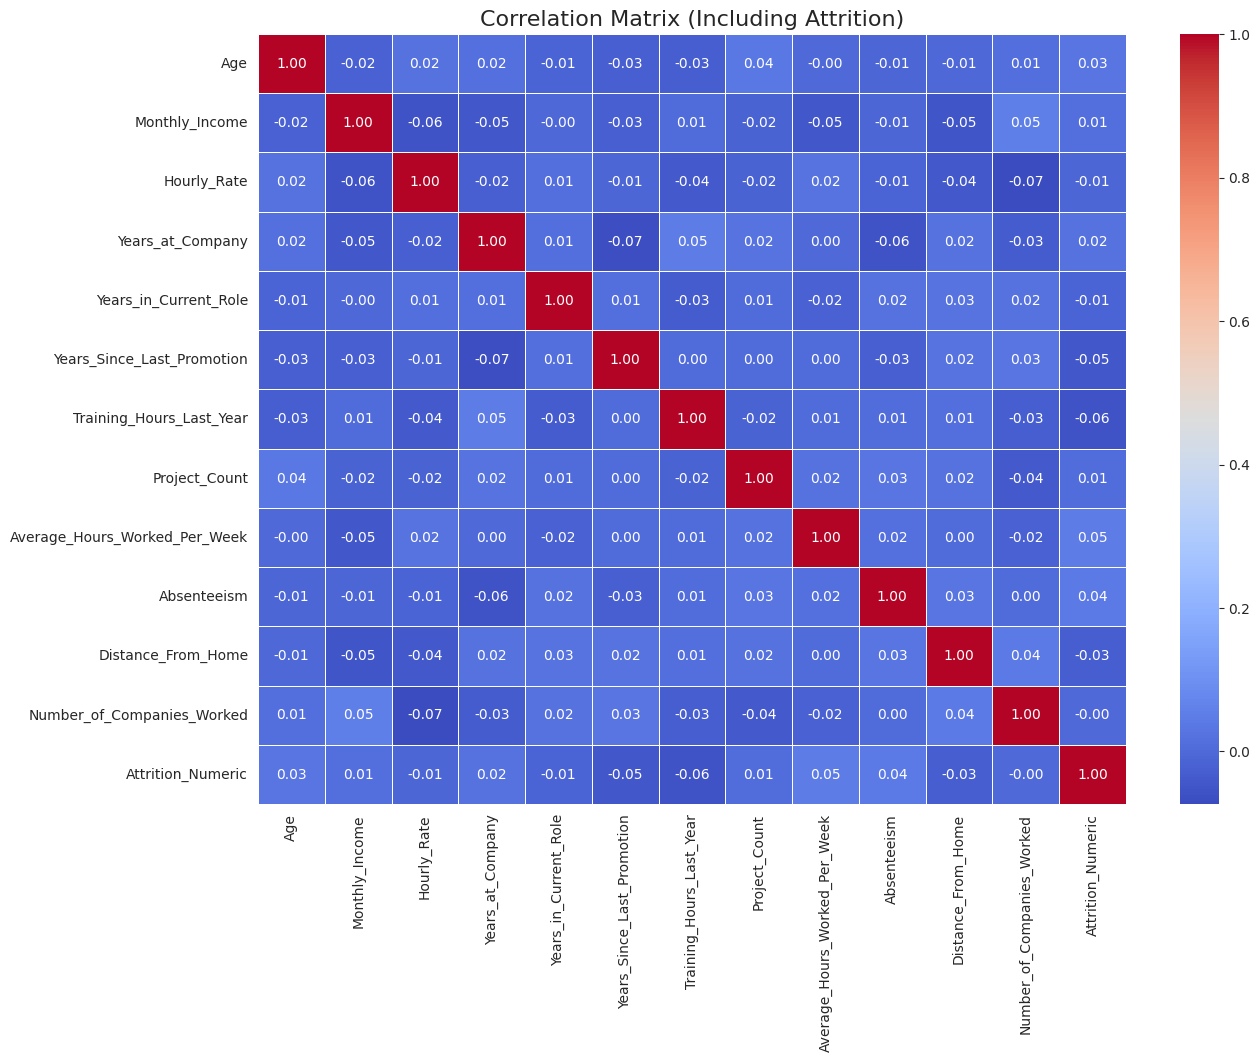

/tmp/ipython-input-1018388478.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Monthly_Income', palette='Set2', ax=axes[0])
/tmp/ipython-input-1018388478.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette='Set2', ax=axes[1])
/tmp/ipython-input-1018388478.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Years_at_Company', palette='Set2', ax=axes[2])


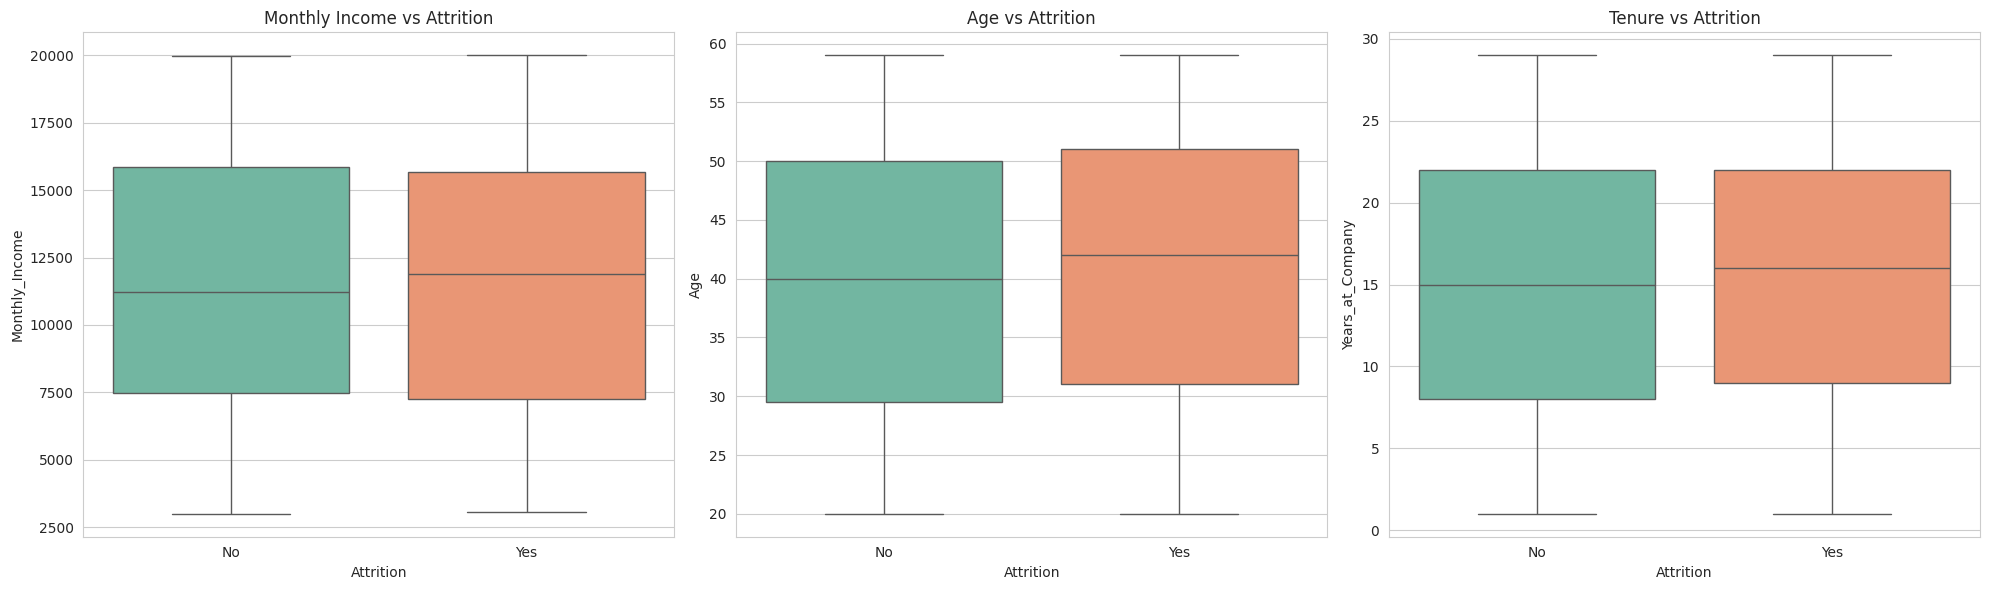

In [8]:
# ---------------------------------------------------------
# 6. CORRELATION & RELATIONSHIPS
# ---------------------------------------------------------
print("\n--- GRID 3: Relationships & Heatmap ---")

# A. Correlation Heatmap
# We create a temporary copy to convert Attrition to Number (1/0) for the heatmap
df_corr = df[num_cols].copy()
df_corr['Attrition_Numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

plt.figure(figsize=(14, 10))
# Plot heatmap using the correlation matrix
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Including Attrition)', fontsize=16)
plt.show()

# B. Boxplots (Key Drivers)
# Visualizing how Income and Tenure vary by Attrition status
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='Attrition', y='Monthly_Income', palette='Set2', ax=axes[0])
axes[0].set_title('Monthly Income vs Attrition')

sns.boxplot(data=df, x='Attrition', y='Age', palette='Set2', ax=axes[1])
axes[1].set_title('Age vs Attrition')

sns.boxplot(data=df, x='Attrition', y='Years_at_Company', palette='Set2', ax=axes[2])
axes[2].set_title('Tenure vs Attrition')

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# PHASE 2: ENCODING & SPLIT
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

In [10]:
# ---------------------------------------------------------
# 1. DEFINE X and y (Do this FIRST)
# ---------------------------------------------------------
# We encode the target manually (Yes=1, No=0)
y = df['Attrition'].map({'Yes': 1, 'No': 0})

# Create the Features DataFrame (Dropping Target and ID)
X = df.drop(columns=['Attrition', 'Employee_ID'])

In [11]:
# ---------------------------------------------------------
# 2. DEFINE YOUR COLUMN LISTS
# ---------------------------------------------------------
# Now that X is defined, we can accurately verify columns

# A. Ordinal Columns (Ranked: Low to High)
ordinal_cols = [
    'Job_Level',
    'Work_Life_Balance',
    'Job_Satisfaction',
    'Performance_Rating',
    'Work_Environment_Satisfaction',
    'Relationship_with_Manager',
    'Job_Involvement'
]

# B. Nominal Columns (Groups: No Order)
nominal_cols = [
    'Gender',
    'Marital_Status',
    'Department',
    'Job_Role',
    'Overtime'
]

# C. Numerical Columns (Math)
# We calculate this dynamically so we don't miss anything
all_cols = X.columns.tolist()
num_cols = [col for col in all_cols if col not in ordinal_cols + nominal_cols]

print(f"Ordinal Cols: {len(ordinal_cols)}")
print(f"Nominal Cols: {len(nominal_cols)}")
print(f"Numerical Cols: {len(num_cols)}")

Ordinal Cols: 7
Nominal Cols: 5
Numerical Cols: 12


In [12]:
# ---------------------------------------------------------
# 3. DEFINE THE PREPROCESSING PIPELINE
# ---------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        # Apply Ordinal Encoder to the 'Ranked' columns
        ('ord', OrdinalEncoder(), ordinal_cols),

        # Apply One-Hot Encoder to the 'Group' columns
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),

        # Apply Scaling to the 'Math' columns
        ('num', StandardScaler(), num_cols)
    ]
)

In [13]:
# ---------------------------------------------------------
# 4. SPLIT THE DATA
# ---------------------------------------------------------
# Split BEFORE transforming features to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Data Split Complete ---")
print(f"Training Data Type: {type(X_train)}") # Should say pandas.core.frame.DataFrame
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}")


--- Data Split Complete ---
Training Data Type: <class 'pandas.core.frame.DataFrame'>
Training Data Shape: (800, 24)
Testing Data Shape:  (200, 24)


--- Model Training & Detailed Evaluation ---


MODEL: Logistic Regression (SMOTE)

--- Training Set Report ---
              precision    recall  f1-score   support

           0       0.85      0.59      0.70       649
           1       0.24      0.55      0.33       151

    accuracy                           0.58       800
   macro avg       0.54      0.57      0.52       800
weighted avg       0.73      0.58      0.63       800


--- Test Set Report ---
              precision    recall  f1-score   support

           0       0.79      0.54      0.64       162
           1       0.16      0.37      0.22        38

    accuracy                           0.51       200
   macro avg       0.47      0.46      0.43       200
weighted avg       0.67      0.51      0.56       200



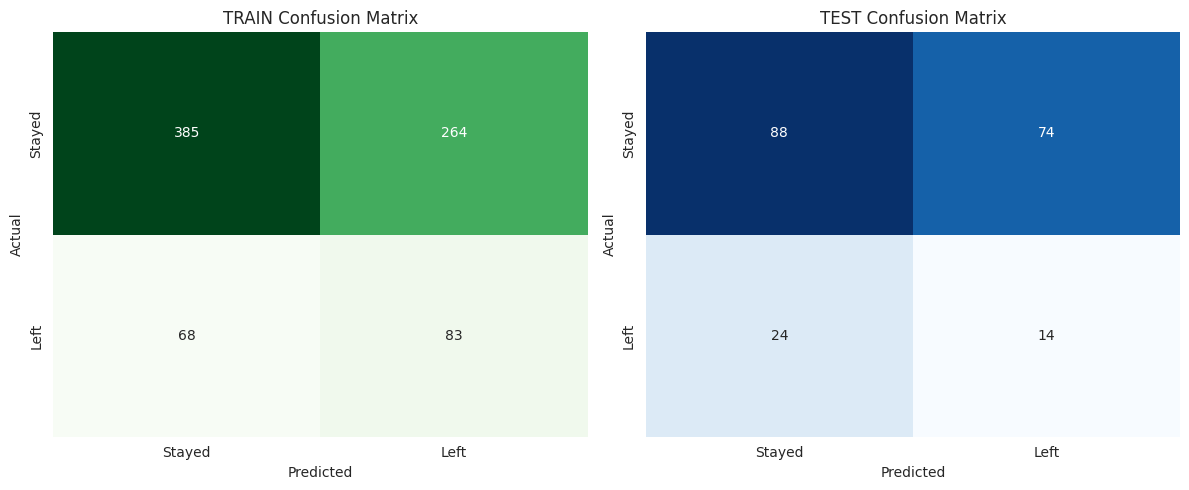


MODEL: Decision Tree (Class Weights)

--- Training Set Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       649
           1       1.00      1.00      1.00       151

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


--- Test Set Report ---
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       162
           1       0.23      0.32      0.27        38

    accuracy                           0.67       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.71      0.67      0.69       200



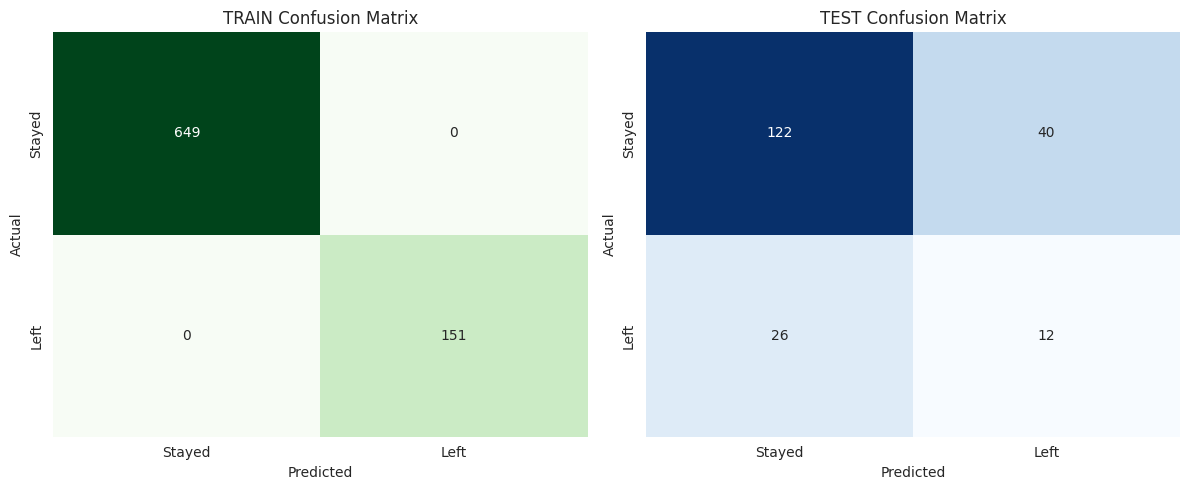

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_


MODEL: Random Forest (Class Weights)

--- Training Set Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       649
           1       1.00      1.00      1.00       151

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


--- Test Set Report ---
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



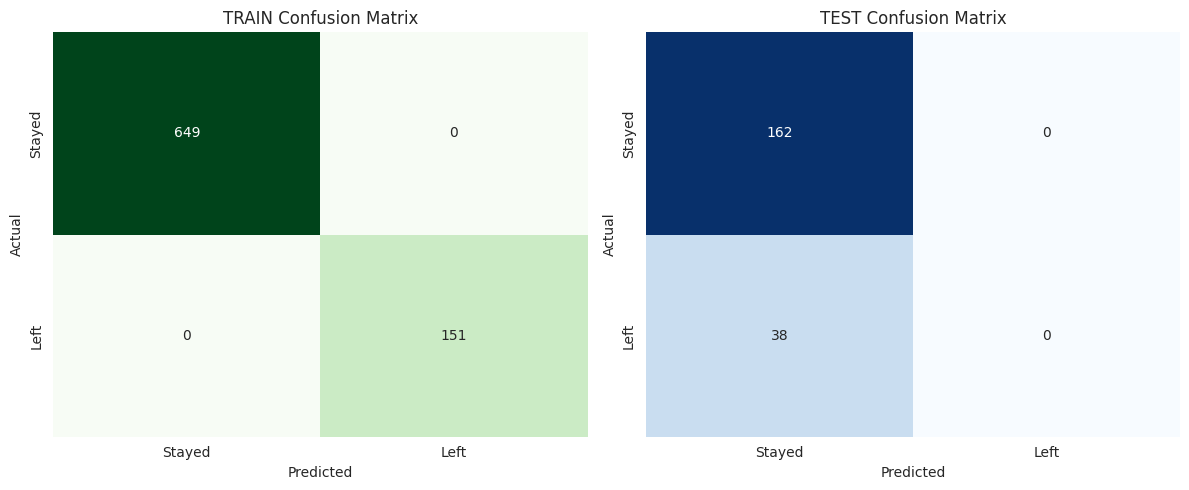

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:27:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL: XGBoost (Class Weights)

--- Training Set Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       649
           1       1.00      1.00      1.00       151

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


--- Test Set Report ---
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       162
           1       0.06      0.03      0.04        38

    accuracy                           0.74       200
   macro avg       0.43      0.47      0.44       200
weighted avg       0.66      0.74      0.70       200



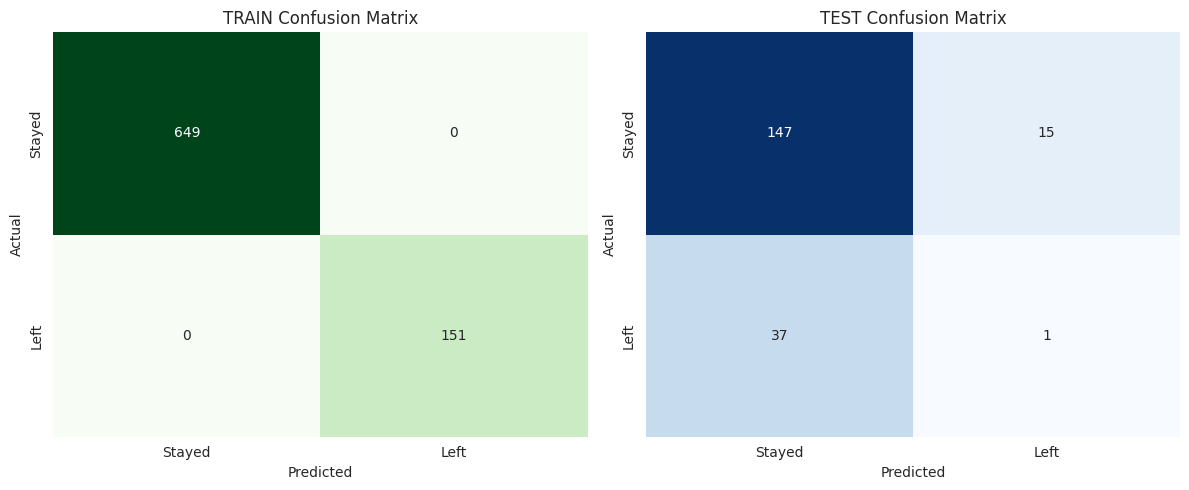


FINAL PERFORMANCE SUMMARY (Sorted by Test Recall)
              Model      Strategy  Train Recall  Test Recall  Train Accuracy  Test Accuracy
Logistic Regression         SMOTE      0.549669     0.368421           0.585           0.51
      Decision Tree Class Weights      1.000000     0.315789           1.000           0.67
            XGBoost Class Weights      1.000000     0.026316           1.000           0.74
      Random Forest Class Weights      1.000000     0.000000           1.000           0.81

(Check for Overfitting: If Train Recall is 1.0 but Test Recall is low, the model is memorizing!)


In [14]:
# ==========================================
# PHASE 3: FULL EVALUATION (TRAIN vs TEST) & SUMMARY
# ==========================================

from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. CALCULATE WEIGHT RATIO FOR XGBOOST
count_no = y_train.value_counts()[0]
count_yes = y_train.value_counts()[1]
xgb_ratio = count_no / count_yes

# 2. DEFINE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=xgb_ratio
    )
}

# 3. TRAINING LOOP
print("--- Model Training & Detailed Evaluation ---\n")

summary_metrics = []

for name, model in models.items():

    # --- CONDITIONAL PIPELINE ---
    if name == "Logistic Regression":
        model_pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
        strategy = "SMOTE"
    else:
        model_pipeline = SklearnPipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        strategy = "Class Weights"

    # --- TRAIN ---
    model_pipeline.fit(X_train, y_train)

    # --- PREDICT ---
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    # --- CALCULATE METRICS ---
    # Train Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_rec = recall_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    # Test Metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    # Add to summary list
    summary_metrics.append({
        'Model': name,
        'Strategy': strategy,
        'Train Recall': train_rec,
        'Test Recall': test_rec,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })

    # --- VISUALIZATION & REPORTS ---
    print(f"\n{'='*60}")
    print(f"MODEL: {name} ({strategy})")
    print(f"{'='*60}")

    # Classification Reports
    print("\n--- Training Set Report ---")
    print(classification_report(y_train, y_train_pred))

    print("\n--- Test Set Report ---")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Train
    cm_train = confusion_matrix(y_train, y_train_pred)
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    axes[0].set_title('TRAIN Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Plot 2: Test
    cm_test = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    axes[1].set_title('TEST Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

# 4. FINAL COMPARISON TABLE
print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY (Sorted by Test Recall)")
print("="*60)

metrics_df = pd.DataFrame(summary_metrics)
# Reorder columns for readability
metrics_df = metrics_df[['Model', 'Strategy', 'Train Recall', 'Test Recall', 'Train Accuracy', 'Test Accuracy']]
metrics_df = metrics_df.sort_values(by='Test Recall', ascending=False)

print(metrics_df.to_string(index=False))

print("\n(Check for Overfitting: If Train Recall is 1.0 but Test Recall is low, the model is memorizing!)")

--- Hyperparameter Tuning Started (Robust Mode) ---

Tuning Logistic Regression...

TUNED MODEL: Logistic Regression
Best Params: {'classifier__solver': 'liblinear', 'classifier__C': 0.01}



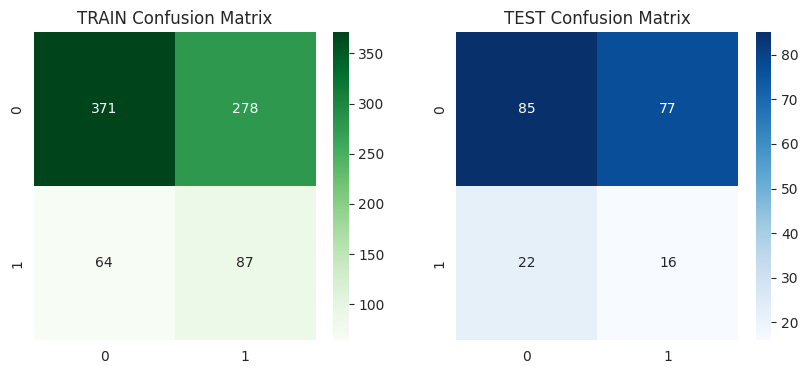

Tuning Decision Tree...

TUNED MODEL: Decision Tree
Best Params: {'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 10, 'classifier__max_depth': 5}



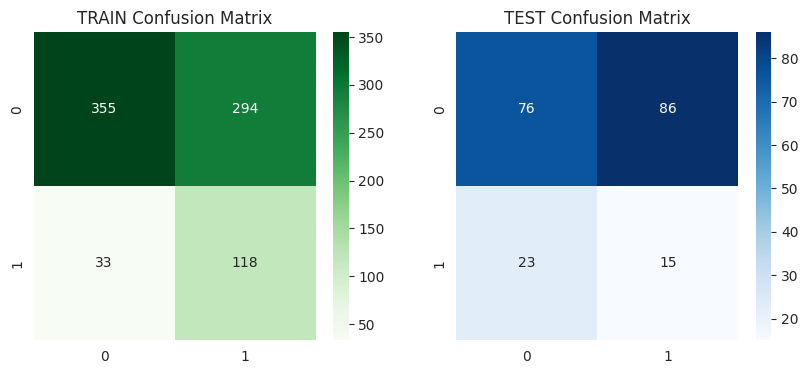

Tuning Random Forest...

TUNED MODEL: Random Forest
Best Params: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': 3}



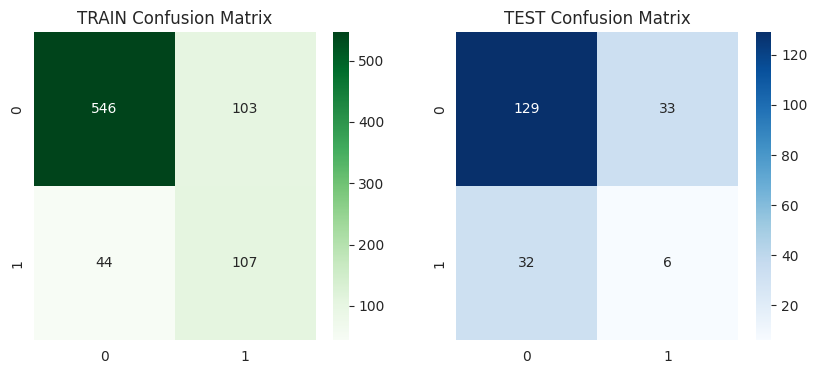

Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:27:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



TUNED MODEL: XGBoost
Best Params: {'classifier__scale_pos_weight': np.float64(6.4470198675496695), 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01}



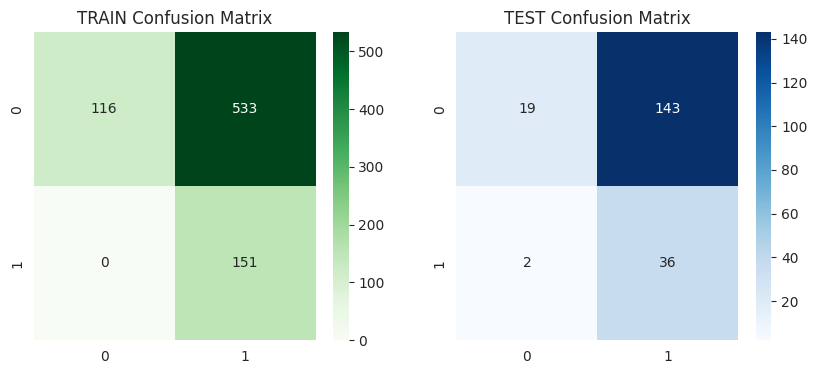


FINAL TUNED LEADERBOARD
              Model  Train Recall  Test Recall  Train Accuracy  Test Accuracy
            XGBoost      1.000000     0.947368         0.33375          0.275
Logistic Regression      0.576159     0.421053         0.57250          0.505
      Decision Tree      0.781457     0.394737         0.59125          0.455
      Random Forest      0.708609     0.157895         0.81625          0.675


In [15]:
# ==========================================
# PHASE 3.5: HYPERPARAMETER TUNING (ROBUST FIX)
# ==========================================

# 1. INSTALL MISSING LIBRARY (Just in case)
!pip install -q imbalanced-learn

from sklearn.model_selection import RandomizedSearchCV
# We use ImbPipeline for EVERYTHING to prevent compatibility errors
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 2. SETUP
count_no = y_train.value_counts()[0]
count_yes = y_train.value_counts()[1]
xgb_ratio = count_no / count_yes

print("--- Hyperparameter Tuning Started (Robust Mode) ---\n")

# 3. DEFINE PARAMETER GRIDS
# Verified: min_samples_split starts at 2. min_samples_leaf starts at 1.
param_grids = {
    "Logistic Regression": {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    "Decision Tree": {
        'classifier__max_depth': [3, 5, 7, 10],
        'classifier__min_samples_split': [2, 5, 10], # MUST be >= 2
        'classifier__min_samples_leaf': [1, 5, 10, 20]
    },

    "Random Forest": {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, 7, 10],
        'classifier__min_samples_split': [5, 10], # MUST be >= 2
        'classifier__min_samples_leaf': [5, 10]
    },

    "XGBoost": {
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__scale_pos_weight': [xgb_ratio, xgb_ratio * 1.5]
    }
}

# 4. BASE MODELS
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 5. TUNING LOOP
tuned_results = []
best_estimators = {}

for name, model in base_models.items():
    print(f"Tuning {name}...")

    # --- BUILD PIPELINE (Unified Strategy) ---
    if name == "Logistic Regression":
        # LogReg gets SMOTE
        steps = [
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ]
    else:
        # Trees get Weights (No SMOTE step)
        # Using ImbPipeline here is safe and standardizes the object type
        steps = [
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]

    pipeline = ImbPipeline(steps)

    # --- RUN RANDOM SEARCH ---
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=10,
        cv=3,
        scoring='recall',
        verbose=0, # Silent to reduce clutter
        n_jobs=-1,
        random_state=42,
        error_score='raise' # Force it to show us real errors if they happen
    )

    try:
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_estimators[name] = best_model

        # --- EVALUATE ---
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        # Metrics
        train_rec = recall_score(y_train, y_train_pred)
        test_rec = recall_score(y_test, y_test_pred)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        tuned_results.append({
            'Model': name,
            'Train Recall': train_rec,
            'Test Recall': test_rec,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc
        })

        # --- VISUALIZATION ---
        print(f"\n{'='*60}")
        print(f"TUNED MODEL: {name}")
        print(f"{'='*60}")
        print(f"Best Params: {search.best_params_}\n")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Greens', ax=axes[0])
        axes[0].set_title('TRAIN Confusion Matrix')
        sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', ax=axes[1])
        axes[1].set_title('TEST Confusion Matrix')
        plt.show()

    except Exception as e:
        print(f"❌ ERROR tuning {name}: {str(e)}")

# 6. FINAL LEADERBOARD
print("\n" + "="*60)
print("FINAL TUNED LEADERBOARD")
print("="*60)

if tuned_results:
    tuned_df = pd.DataFrame(tuned_results)
    tuned_df = tuned_df[['Model', 'Train Recall', 'Test Recall', 'Train Accuracy', 'Test Accuracy']]
    tuned_df = tuned_df.sort_values(by='Test Recall', ascending=False)
    print(tuned_df.to_string(index=False))
else:
    print("No models finished tuning successfully.")

In [16]:
!pip install shap

In [17]:
# ==========================================
# PHASE 4 SETUP: TRAIN & STORE MODELS (INCL. DEEP LEARNING)
# ==========================================
import shap
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

# ---------------------------------------------------------
# 1. CUSTOM WRAPPER FOR NEURAL NETWORK
# ---------------------------------------------------------
# This class makes the Neural Net look like a standard Sklearn Model
# so it works seamlessly with your Copilot interface.
class NeuralNetworkPipeline(BaseEstimator, ClassifierMixin):
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.model = None
        self.named_steps = {'preprocessor': preprocessor} # Trick for Copilot compatibility

    def fit(self, X, y):
        # 1. Transform Data (NN needs float32)
        X_trans = self.preprocessor.fit_transform(X).astype('float32')
        y_vals = y.values.astype('float32') if hasattr(y, 'values') else y.astype('float32')

        # 2. Build Architecture (Dynamic input shape)
        self.model = Sequential([
            Dense(64, activation='relu', input_shape=(X_trans.shape[1],)),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # 3. Train
        stopper = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        self.model.fit(X_trans, y_vals, epochs=50, batch_size=32,
                       class_weight={0: 1.0, 1: 4.0}, verbose=0, callbacks=[stopper])

        # Update named steps so Copilot can find the model later
        self.named_steps['classifier'] = self.model
        return self

    def predict_proba(self, X):
        # Transform input
        X_trans = self.preprocessor.transform(X).astype('float32')
        # Get probability (0-1)
        prob_pos = self.model.predict(X_trans, verbose=0)
        # Format like sklearn: [[prob_0, prob_1], ...]
        return np.hstack([1 - prob_pos, prob_pos])

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs[:, 1] > 0.5).astype(int)

# ---------------------------------------------------------
# 2. SETUP MODELS & CONFIG
# ---------------------------------------------------------
count_no = y_train.value_counts()[0]
count_yes = y_train.value_counts()[1]
xgb_ratio = count_no / count_yes

# Define Standard ML Models
model_configs = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=xgb_ratio, max_depth=3)
}

# ---------------------------------------------------------
# 3. TRAIN & SAVE TO DICTIONARY
# ---------------------------------------------------------
trained_pipelines = {}
print("Training models for Copilot...")

# A. Train Standard ML Models
for name, model in model_configs.items():
    if name == "Logistic Regression":
        pipe = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
    else:
        pipe = SklearnPipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"✅ {name} stored.")

# B. Train Neural Network (Custom Pipeline)
print("⏳ Training Neural Network (Deep Learning)...")
dl_pipeline = NeuralNetworkPipeline(preprocessor)
dl_pipeline.fit(X_train, y_train)
trained_pipelines["Neural Network"] = dl_pipeline
print(f"✅ Neural Network stored.")

print("\nAll models ready for the Copilot!")

Training models for Copilot...
✅ Logistic Regression stored.
✅ Decision Tree stored.
✅ Random Forest stored.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:28:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost stored.
⏳ Training Neural Network (Deep Learning)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Neural Network stored.

All models ready for the Copilot!


In [18]:
# ==========================================
# PHASE 5: VELORIUM COPILOT (WITH DL SUPPORT)
# ==========================================
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
import google.generativeai as genai
import pandas as pd
import numpy as np
import shap
import getpass

# ---------------------------------------------------------
# 1. SETUP GEMINI API
# ---------------------------------------------------------
print("🔑 ENTER YOUR GEMINI API KEY:")
api_key = getpass.getpass()
genai.configure(api_key=api_key)

# Auto-select best model (handling Colab versions)
try:
    models = [m.name for m in genai.list_models()]
    model_name = 'gemini-2.5-flash' if 'models/gemini-2.5-flash' in models else 'gemini-pro'
    llm_model = genai.GenerativeModel(model_name)
    print(f"✅ Gemini API Configured! (Using {model_name})")
except:
    llm_model = genai.GenerativeModel('gemini-2.5-flash')
    print("✅ Gemini API Configured! (Defaulting to 2.5-flash)")

# ---------------------------------------------------------
# 2. HELPER: GENERATE PROMPT
# ---------------------------------------------------------
def generate_prompt_for_gemini(employee_id, risk_prob, top_factors, employee_data):
    dept = employee_data['Department'].values[0]
    role = employee_data['Job_Role'].values[0]
    tenure = employee_data['Years_at_Company'].values[0]

    risk_level = "CRITICAL" if risk_prob > 0.7 else "HIGH" if risk_prob > 0.5 else "MODERATE" if risk_prob > 0.3 else "LOW"

    drivers_list = ""
    for idx, row in top_factors.iterrows():
        clean_name = row['Feature'].replace('cat__', '').replace('num__', '').replace('ord__', '')
        direction = "INCREASING risk" if row['Impact_Value'] > 0 else "DECREASING risk"
        drivers_list += f"- {clean_name}: {direction} (Impact: {row['Impact_Value']:.3f})\n"

    prompt = f"""
    You are 'Velorium Copilot', an expert HR AI Advisor.

    TARGET EMPLOYEE PROFILE:
    - ID: {employee_id}
    - Role: {role} in {dept} Department
    - Tenure: {tenure} Years

    RISK ANALYSIS:
    - Attrition Probability: {risk_prob:.1%} ({risk_level} Risk)

    TOP BEHAVIORAL DRIVERS (SHAP Analysis):
    {drivers_list}

    YOUR MISSION:
    Write a strategic retention plan for this employee's manager.

    OUTPUT FORMAT (Use Markdown):
    ### 🚨 Risk Assessment
    [Summarize in 2 sentences. Is this burnout? Stagnation?]

    ### 🔍 Root Cause Analysis
    [Explain the top 2 drivers in simple English.]

    ### 💡 Action Plan (Next 14 Days)
    1. **[Action 1]**: [Specific instruction]
    2. **[Action 2]**: [Specific instruction]

    ### 💬 Conversation Script (For 1:1)
    "manager_script": "[A polite opening line for the manager]"
    """
    return prompt

# ---------------------------------------------------------
# 3. THE COPILOT ENGINE (UPDATED FOR DL)
# ---------------------------------------------------------
def run_full_copilot_logic(emp_id, model_name):

    # A. Validate & Fetch Data
    if emp_id not in df['Employee_ID'].values:
        return None, "❌ Error: Employee Not Found"

    row = df[df['Employee_ID'] == emp_id].copy()

    # B. Model Prediction
    pipeline = trained_pipelines[model_name]

    # Handle Custom Neural Network Wrapper vs Standard Pipeline
    if model_name == "Neural Network":
        prep_step = pipeline.preprocessor # Accessed directly from wrapper
        model_step = pipeline.model       # Keras model
    else:
        prep_step = pipeline.named_steps['preprocessor']
        model_step = pipeline.named_steps['classifier']

    X_in = row.drop(columns=['Employee_ID', 'Attrition'], errors='ignore')
    X_proc = prep_step.transform(X_in)

    # Predict
    if model_name == "Neural Network":
        X_proc = X_proc.astype('float32') # DL needs float32
        prob_raw = model_step.predict(X_proc, verbose=0)[0][0]
        prob = float(prob_raw)
    else:
        prob = model_step.predict_proba(X_proc)[0][1]

    # Explain (SHAP) - Now handles Neural Networks!
    shap.initjs()

    if model_name == "Logistic Regression":
        explainer = shap.LinearExplainer(model_step, prep_step.transform(X_train[:50]))
        shap_values = explainer.shap_values(X_proc)
        vals = shap_values[0] # Linear usually returns array directly

    elif model_name == "Neural Network":
        # Use KernelExplainer for DL (Model Agnostic)
        # We need a prediction function wrapper for SHAP
        def dl_predict(data):
            return model_step.predict(data.astype('float32'), verbose=0).flatten()

        # Use small background for speed
        background = prep_step.transform(X_train[:10]).astype('float32')
        explainer = shap.KernelExplainer(dl_predict, background)

        # Calculate SHAP (nsamples controls speed/accuracy)
        shap_values = explainer.shap_values(X_proc, nsamples=50, silent=True)
        vals = shap_values[0] # Kernel returns list [values]

    else:
        # Tree Models
        explainer = shap.TreeExplainer(model_step)
        shap_values = explainer.shap_values(X_proc)
        vals = shap_values[1][0] if isinstance(shap_values, list) else shap_values[0]

    # Get Feature Names
    try:
        feats = prep_step.get_feature_names_out()
    except:
        feats = [f"F{i}" for i in range(len(vals))]

    # Extract Top 5
    shap_df = pd.DataFrame({'Feature': feats, 'Impact_Value': vals})
    shap_df['Abs'] = shap_df['Impact_Value'].abs()
    top_5 = shap_df.sort_values('Abs', ascending=False).head(5)

    return prob, top_5, row

# ---------------------------------------------------------
# 4. THE INTERFACE
# ---------------------------------------------------------
header = widgets.HTML("<h2>🤖 Velorium HR Copilot (Powered by Gemini)</h2>")
id_input = widgets.IntText(value=23, description='Employee ID:')
# Update dropdown to include all trained models
model_select = widgets.Dropdown(options=list(trained_pipelines.keys()), value='Logistic Regression', description='Model:')
btn_analyze = widgets.Button(description="Generate Retention Plan", button_style='success', icon='magic')
output_display = widgets.Output()

def on_analyze_click(b):
    with output_display:
        clear_output()
        print(f"⏳ Analyzing ID #{id_input.value} using {model_select.value}...")

        try:
            result = run_full_copilot_logic(id_input.value, model_select.value)
            if result[0] is None:
                print(result[1])
                return

            prob, top_5, emp_data = result

            print(f"✅ Risk Probability: {prob:.1%}")
            print("⏳ Consulting Gemini AI...")

            final_prompt = generate_prompt_for_gemini(id_input.value, prob, top_5, emp_data)
            response = llm_model.generate_content(final_prompt)

            clear_output()
            color = "red" if prob > 0.5 else "green"
            display(widgets.HTML(f"<h3 style='color:{color}'>Attrition Risk: {prob:.1%}</h3>"))

            print("--- 🔍 TOP RISK DRIVERS (SHAP) ---")
            display(top_5[['Feature', 'Impact_Value']])

            print("\n--- 🧠 STRATEGIC PLAN (Gemini) ---")
            display(Markdown(response.text))

        except Exception as e:
            print(f"❌ Error: {e}")
            print("Check your API Key or try a different model.")

btn_analyze.on_click(on_analyze_click)
display(header, id_input, model_select, btn_analyze, output_display)

🔑 ENTER YOUR GEMINI API KEY:
··········
✅ Gemini API Configured! (Using gemini-2.5-flash)


HTML(value='<h2>🤖 Velorium HR Copilot (Powered by Gemini)</h2>')

IntText(value=23, description='Employee ID:')

Dropdown(description='Model:', options=('Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'N…

Button(button_style='success', description='Generate Retention Plan', icon='magic', style=ButtonStyle())

Output()

--- generating 3D Noise Plot ---


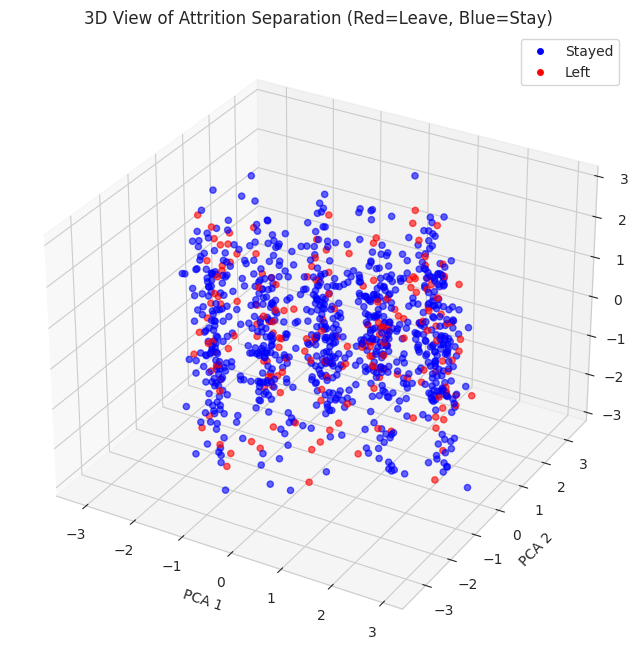

In [19]:
# ==========================================
# VISUALIZATION: 3D DATA OVERLAP CHECK
# ==========================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np

print("--- generating 3D Noise Plot ---")

# 1. Preprocess the Entire Dataset
# We need to turn text into numbers first using the pipeline we built
X_processed = preprocessor.fit_transform(X)

# 2. Reduce to 3 Dimensions (PCA)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_processed)

# 3. Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Color mapping: Blue (0/Stay), Red (1/Leave)
colors = y.map({0: 'blue', 1: 'red'})

# Scatter Plot
scatter = ax.scatter(
    X_pca[:, 0], # X-axis
    X_pca[:, 1], # Y-axis
    X_pca[:, 2], # Z-axis
    c=colors,    # Colors
    alpha=0.6,   # Transparency
    s=20         # Dot size
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('3D View of Attrition Separation (Red=Leave, Blue=Stay)')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Stayed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Left')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

In [20]:
# ==========================================
# PHASE 6: FINAL SAVE (CLEANING UP)
# ==========================================
import joblib
from google.colab import files

print("Packaging ONLY the working models...")

# 1. Create a clean dictionary with only the SUCCESSFUL models
# We assume 'trained_pipelines' currently holds everything.
# We will manually pick the ones we want to keep.

final_models_dict = {}

# Add Logistic Regression (The Champion)
if 'Logistic Regression' in trained_pipelines:
    final_models_dict['Logistic Regression'] = trained_pipelines['Logistic Regression']

# Add XGBoost (The ML Challenger)
if 'XGBoost' in trained_pipelines:
    final_models_dict['XGBoost'] = trained_pipelines['XGBoost']

# Add Neural Network (The DL Challenger)
if 'Neural Network' in trained_pipelines:
    final_models_dict['Neural Network'] = trained_pipelines['Neural Network']

print(f"✅ Saving {len(final_models_dict)} models: {list(final_models_dict.keys())}")

# 2. Save to file
joblib.dump(final_models_dict, 'velorium_models_dict.pkl')
df.to_csv('velorium_data.csv', index=False)

# 3. Download
files.download('velorium_models_dict.pkl')
files.download('velorium_data.csv')

Packaging ONLY the working models...
✅ Saving 3 models: ['Logistic Regression', 'XGBoost', 'Neural Network']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>